# Social Media User Engagement Clustering

Group Facebook posts into behaviour segments based on how much engagement they got.
Dataset: Facebook Metrics dataset (Moro, Rita and Vala, 2016), 500 posts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


## 1. Load the data

In [2]:
csv_data = """Page total likes;Type;Category;Post Month;Post Weekday;Post Hour;Paid;Lifetime Post Total Reach;Lifetime Post Total Impressions;Lifetime Engaged Users;Lifetime Post Consumers;Lifetime Post Consumptions;Lifetime Post Impressions by people who have liked your Page;Lifetime Post reach by people who like your Page;Lifetime People who have liked your Page and engaged with your post;comment;like;share;Total Interactions
139441;Photo;2;12;4;3;0;2752;5091;178;109;159;3078;1640;119;4;79;17;100
139441;Status;2;12;3;10;0;10460;19057;1457;1361;1674;11710;6112;1108;5;130;29;164
139441;Photo;3;12;3;3;0;2413;4373;177;113;154;2812;1503;132;0;66;14;80
139441;Photo;2;12;2;10;1;50128;87991;2211;790;1119;61027;32048;1386;58;1572;147;1777
139441;Photo;2;12;2;3;0;7244;13594;671;410;580;6228;3200;396;19;325;49;393
139441;Status;2;12;1;9;0;10472;20849;1191;1073;1389;16034;7852;1016;1;152;33;186
139441;Photo;3;12;1;3;1;11692;19479;481;265;364;15432;9328;379;3;249;27;279
139441;Photo;3;12;7;9;1;13720;24137;537;232;305;19728;11056;422;0;325;14;339
139441;Status;2;12;7;3;0;11844;22538;1530;1407;1692;15220;7912;1250;0;161;31;192
139441;Photo;3;12;6;10;0;4694;8668;280;183;250;4309;2324;199;3;113;26;142
139441;Status;2;12;5;10;0;21744;42334;4258;4100;4540;37849;18952;3798;0;233;19;252
139441;Photo;2;12;5;10;0;3112;5590;208;127;145;3887;2174;165;0;88;18;106
139441;Photo;2;12;5;10;0;2847;5133;193;115;133;3779;2072;152;0;90;14;104
139441;Photo;2;12;5;3;0;2549;4896;249;134;168;3631;1917;183;5;137;10;152
138414;Photo;2;12;4;5;1;22784;39941;887;337;417;34415;19312;684;2;577;20;599
138414;Status;2;12;3;10;0;10060;19680;1264;1209;1425;17272;8548;1162;4;86;18;108
138414;Photo;3;12;3;3;0;1722;2981;163;123;148;1868;1050;123;2;40;12;54
138414;Photo;1;12;2;12;1;53264;111785;1706;1103;1655;92512;39776;1307;15;678;20;713
138414;Status;3;12;2;3;0;3930;7509;130;86;112;5009;2410;101;4;54;17;75
138414;Photo;3;12;1;11;0;1591;2825;121;88;111;2116;1161;100;0;34;8;42
138414;Photo;2;12;1;3;0;2848;5066;200;142;184;3561;1963;157;3;66;12;81
138414;Photo;1;12;7;10;0;1384;2467;15;15;20;2196;1172;15;0;0;0;0
138414;Link;1;12;7;10;0;3454;6853;118;104;130;6282;3100;106;0;16;2;18
138414;Photo;3;12;7;3;0;2723;4888;176;118;143;2964;1621;143;0;72;24;96
138414;Status;2;12;6;10;0;8488;15294;1341;1270;1489;9684;5244;995;3;99;19;121
138458;Status;2;12;6;3;0;8284;15104;1521;1462;1711;10266;5372;1200;0;88;18;106
138458;Status;2;12;5;11;0;19552;34143;2806;2531;3420;17748;9824;1779;10;412;72;494
138458;Photo;3;12;5;3;0;2478;4306;212;124;149;2612;1443;166;0;100;17;117
138895;Photo;2;12;5;3;0;9560;18264;973;559;885;9217;4748;621;36;523;63;622
138895;Video;1;12;4;11;1;36208;61262;1141;1068;1728;30131;14112;559;18;143;13;174
138895;Photo;2;12;4;2;0;4940;9390;385;306;501;5860;2930;273;33;107;22;162
138895;Photo;2;12;3;10;0;1683;2929;192;171;221;1585;858;131;1;27;11;39
138895;Photo;3;12;3;3;0;5280;9578;368;237;345;4480;2422;268;2;155;47;204
138895;Photo;3;12;2;9;0;3002;5318;268;185;247;3039;1676;194;4;98;23;125
138895;Photo;1;12;2;3;0;3766;7149;298;260;431;5782;2938;244;2;56;17;75
138895;Photo;2;12;1;11;0;4512;7808;423;284;431;5183;2954;316;6;172;21;199
138895;Photo;3;12;1;3;0;2690;4628;252;168;226;3052;1727;199;0;96;17;113
138895;Photo;1;12;7;10;1;19800;28663;479;424;805;5187;2752;248;16;76;8;100
138895;Status;2;12;7;9;0;17576;33058;5352;5202;6547;23135;11792;4104;11;227;31;269
138895;Photo;1;12;7;3;0;3290;6085;306;284;402;4986;2584;247;1;44;14;59
138895;Status;2;12;6;11;0;13280;24198;2055;1912;2720;17627;9344;1716;7;216;39;262
138895;Link;1;12;6;3;1;18480;28438;517;366;460;12078;6752;319;6;187;18;211
138353;Photo;1;12;5;10;0;7268;13989;2087;2079;12074;13544;7096;1975;7;26;3;36
138353;Link;1;12;5;3;1;2645;4270;134;109;170;2330;1377;101;7;29;10;46
138353;Photo;1;12;4;11;0;4284;8387;355;316;513;7283;3634;291;0;47;11;58
138353;Link;1;12;4;3;1;7968;13023;206;158;223;6734;3492;138;4;57;10;71
138353;Status;1;12;3;11;0;16576;30612;3572;3464;4802;24363;12888;3014;4;174;36;214
138353;Link;1;12;3;2;0;1925;3481;97;83;126;2307;1180;77;6;18;8;32
138353;Photo;1;12;2;11;0;3786;7329;338;283;450;6336;3216;280;0;77;15;92
138353;Link;1;12;2;2;0;1536;3094;84;76;99;2903;1407;76;1;12;1;14
138353;Photo;2;11;1;9;0;1728;3155;108;65;95;2313;1232;77;1;48;9;58
138329;Photo;1;11;1;3;1;25248;40125;726;467;863;16132;8608;451;24;285;28;337
138329;Photo;1;11;7;9;0;4894;8899;355;181;264;4914;2712;246;9;202;31;242
138329;Photo;1;11;7;3;0;2935;5439;237;182;401;3901;2044;201;4;64;19;87
138329;Photo;1;11;6;10;0;2425;4462;260;213;433;3017;1510;175;4;66;13;83
138329;Video;1;11;6;2;1;16416;31950;459;411;539;21436;9568;363;2;65;14;81
138329;Photo;1;11;5;11;0;5812;10465;343;204;301;4976;2764;240;2;164;54;220
138329;Photo;1;11;5;3;0;2545;4846;165;131;167;3675;1901;134;0;40;13;53
138329;Photo;1;11;4;10;0;2257;4372;230;173;327;3188;1557;168;3;76;11;90
138329;Photo;1;11;4;3;1;27072;84885;421;304;487;35637;9712;263;4;139;17;160
138185;Photo;1;11;3;11;1;10940;27951;417;335;591;15066;5100;319;8;101;14;123
138185;Photo;1;11;3;2;1;50912;164528;630;513;952;54653;12704;346;8;144;10;162
138185;Photo;1;11;2;10;1;28752;47358;802;654;1268;14091;7456;408;10;179;13;202
138185;Photo;1;11;2;3;1;27216;81908;541;335;540;26869;7760;315;4;219;22;245
138185;Photo;1;11;1;10;0;2352;5234;232;182;258;4101;1761;181;2;60;7;69
138185;Photo;1;11;1;3;0;3416;6167;356;298;641;4530;2388;280;19;77;23;119
138185;Photo;1;11;7;11;0;2149;4120;197;156;219;3302;1640;161;0;48;7;55
138185;Photo;1;11;7;3;1;53456;93790;1576;995;1469;32646;14912;884;20;697;70;787
138185;Photo;1;11;6;11;0;2168;3891;211;168;202;2873;1539;171;0;53;17;70
137893;Photo;1;11;6;3;0;3102;5939;360;288;512;3537;1780;275;7;84;28;119
137893;Photo;1;11;5;10;1;39344;103050;588;460;695;39304;11392;336;7;146;9;162
137893;Video;1;11;5;3;1;100768;220447;2101;1735;2331;59658;18880;885;17;449;84;550
137893;Status;3;11;4;11;0;9056;16362;1006;847;1153;9562;5180;740;3;226;44;273
137893;Photo;1;11;4;2;1;11444;46054;555;418;717;13737;4320;438;14;172;47;233
137893;Video;1;11;3;11;0;13544;30235;517;458;667;26622;11760;447;2;99;13;114
137893;Photo;1;11;3;2;1;37376;68610;1150;808;1341;22100;10880;724;20;411;74;505
137893;Photo;1;11;3;2;0;1228;2392;17;17;19;2392;1228;17;0;0;0;0
137177;Photo;1;11;1;10;0;22984;59040;438;374;542;12716;4968;262;4;85;8;97
137177;Photo;2;11;1;3;0;1445;2774;217;167;211;1924;1005;154;0;56;8;64
137177;Photo;1;11;7;12;0;3754;8533;658;640;2085;6838;3224;598;2;29;7;38
137177;Status;2;11;7;3;0;8728;17827;2295;2235;2828;15418;7344;2099;2;86;13;101
137177;Photo;3;11;6;10;0;5990;11123;657;361;512;5057;2628;428;18;370;53;441
137177;Photo;1;11;6;3;0;4582;9193;454;306;431;3691;1722;305;5;190;57;252
137177;Photo;3;11;5;10;1;2938;5799;321;243;379;3668;1848;236;2;101;19;122
137177;Status;3;11;5;2;0;6692;13092;199;108;141;7549;3336;156;2;99;16;117
137177;Photo;1;11;4;9;1;2566;5244;384;280;469;3834;1806;266;10;140;8;158
137177;Link;1;11;4;3;0;21176;54779;330;228;329;13858;5248;185;2;130;31;163
137177;Photo;3;11;3;10;0;4012;7955;550;319;477;4625;2218;403;3;270;38;311
137177;Photo;1;11;3;3;0;1531;2838;212;189;1359;1210;690;143;3;30;6;39
137059;Photo;1;11;2;11;1;2938;6056;374;283;483;4509;2078;287;2;107;17;126
137059;Photo;1;11;2;3;0;24720;37240;845;564;850;14475;8120;504;13;331;77;421
137059;Photo;2;11;1;9;0;2219;4545;287;220;329;3189;1495;221;0;78;13;91
137059;Photo;3;11;1;3;0;4732;9303;607;352;518;6201;3136;445;9;301;32;342
137059;Photo;3;11;7;9;0;2225;4239;310;216;289;2570;1389;233;2;111;16;129
137059;Photo;2;11;7;4;0;2626;4943;316;213;299;3047;1605;244;2;124;22;148
137059;Photo;3;10;6;10;0;3090;5744;391;257;360;3521;1796;293;5;153;27;185
137059;Photo;1;10;6;3;0;1101;2548;324;287;2418;1284;704;220;3;51;11;65
137059;Photo;2;10;5;11;0;2819;5230;318;218;303;3128;1622;240;1;115;26;142
137020;Status;2;10;5;3;1;12468;24917;2143;1966;2576;15850;7636;1661;7;310;61;378
137020;Photo;1;10;4;10;0;12776;21893;785;539;881;13272;7800;575;12;328;90;430
137020;Photo;1;10;4;9;1;1357;2453;37;37;55;2154;1120;32;0;0;0;0
137020;Photo;2;10;4;3;0;68896;104952;2624;1326;1952;35707;19840;1354;26;1505;95;1626
137020;Photo;3;10;3;10;0;1711;3174;288;245;339;2226;1118;205;2;63;14;79
137020;Photo;1;10;3;4;0;1388;2544;224;219;931;2161;1214;172;0;13;4;17
137020;Photo;1;10;2;11;1;2645;5472;357;315;482;4485;2101;265;4;59;9;72
137020;Photo;1;10;2;4;0;70144;111745;3216;2628;4782;43671;20608;1542;42;955;139;1136
137020;Photo;3;10;1;11;0;3674;7221;452;330;487;3832;1890;328;9;181;32;222
136736;Status;2;10;1;4;0;9504;19556;1132;1032;1512;16018;7616;981;17;193;28;238
136736;Photo;3;10;7;9;0;2426;4469;320;237;325;3120;1684;248;7;125;16;148
136736;Status;2;10;7;3;0;13872;27468;2664;2570;3395;20198;10432;2252;4;217;50;271
136736;Photo;1;10;6;10;0;1673;3655;338;324;1619;2598;1469;268;2;28;4;34
136736;Photo;1;10;6;8;0;1261;2158;37;37;49;1911;1077;33;0;;;0
136736;Photo;2;10;6;4;0;2428;4510;311;238;323;2888;1560;236;4;117;18;139
136642;Photo;2;10;1;3;1;2227;4070;369;314;430;3227;1702;306;2;79;16;97
136642;Photo;1;10;7;13;0;1592;2749;370;356;414;2551;1454;327;0;15;2;17
136642;Photo;1;10;7;12;1;813;1568;323;319;387;1402;695;280;0;4;2;6
136642;Photo;1;10;7;12;0;32208;57472;1810;1490;2286;56149;31648;1724;1;431;26;458
136642;Photo;1;10;7;11;0;729;1374;303;298;331;1284;650;262;0;7;0;7
136642;Photo;1;10;7;10;0;834;1570;399;392;510;1390;704;351;0;7;2;9
136393;Photo;1;10;7;10;0;786;1573;263;257;318;1401;660;222;0;6;2;8
136393;Photo;1;10;7;9;0;584;1029;273;271;308;943;511;232;0;2;;2
136393;Status;2;10;7;9;0;15816;30514;2733;2654;3289;23584;11912;2361;6;186;40;232
136393;Photo;1;10;7;8;0;619;1096;257;254;292;951;516;217;1;1;2;4
136393;Photo;1;10;7;7;0;617;1071;229;223;265;935;521;191;1;3;2;6
136393;Photo;1;10;7;6;0;677;1285;251;246;297;1210;615;211;0;7;;7
136393;Photo;1;10;7;5;0;677;1240;236;228;264;1098;580;196;0;7;2;9
136393;Photo;3;10;7;3;0;3366;6647;474;345;495;3180;1674;385;3;198;41;242
136393;Photo;1;10;6;13;0;747;1443;226;220;287;1252;632;194;0;9;1;10
136393;Photo;1;10;6;13;0;645;1117;195;192;224;989;554;166;0;4;1;5
136393;Photo;1;10;6;12;0;754;1510;206;205;252;1430;690;175;0;3;0;3
136393;Photo;1;10;6;11;0;910;1673;207;201;247;1503;782;176;0;8;2;10
136393;Photo;1;10;6;9;0;3906;8239;868;863;2632;7736;3768;774;0;7;3;10
136393;Photo;1;10;6;9;0;659;1158;199;194;239;1041;576;169;1;7;2;10
136393;Photo;1;10;6;8;0;652;1331;214;206;249;1249;588;182;0;11;1;12
136393;Photo;1;10;6;6;0;861;1565;214;192;239;1351;717;180;2;28;4;34
136393;Photo;1;10;6;2;0;3690;7659;424;388;644;6951;3290;377;0;56;12;68
136393;Link;1;10;5;10;0;4664;9463;204;182;251;7196;3324;173;0;32;16;48
136013;Photo;1;10;5;8;0;1080;2427;210;189;249;2195;934;184;4;32;3;39
136013;Status;2;10;5;3;0;8896;17202;1480;1426;1932;13838;7020;1292;0;129;25;154
136013;Photo;1;10;4;10;1;4018;8617;428;374;616;6677;2992;351;4;77;19;100
136013;Link;1;10;4;3;0;68992;229733;1032;975;1345;17842;8032;635;15;143;44;202
136013;Status;3;10;3;10;0;13152;25666;2543;2438;3179;20547;10280;2278;2;227;36;265
136013;Status;2;10;3;2;1;31136;59964;6164;5934;9237;35977;18048;4376;60;859;90;1009
136013;Photo;3;10;2;10;1;16776;39549;714;440;720;11860;6200;590;10;377;60;447
136013;Photo;1;10;2;3;1;50736;140432;1462;1450;8308;46252;15552;1275;3;41;9;53
136013;Photo;1;10;1;10;1;5324;11040;528;483;861;8627;4054;448;6;76;14;96
136013;Photo;3;10;1;3;0;18120;44940;421;282;463;4401;2616;327;0;189;15;204
135713;Photo;3;10;7;10;0;2291;3960;303;243;325;3020;1723;253;0;80;14;94
135713;Status;2;10;7;4;0;10744;20691;1967;1877;2201;17502;8964;1834;3;148;28;179
135713;Link;1;10;6;11;1;3616;6887;111;90;118;4263;2138;93;0;24;11;35
135713;Photo;1;10;6;4;0;39984;112830;2105;1921;3932;70249;21328;1609;24;302;41;367
135713;Photo;2;10;5;11;0;4010;7444;477;370;534;4406;2362;354;2;166;32;200
135713;Photo;2;10;5;4;1;6564;12097;806;602;957;7682;4024;563;47;358;49;454
135713;Photo;1;10;4;10;0;8612;20151;813;727;1390;16890;7208;630;7;161;25;193
135713;Photo;2;10;4;1;0;5568;10282;746;545;867;5696;3162;537;13;319;55;387
135700;Photo;2;9;3;7;0;1685;2999;322;295;424;1794;953;237;0;54;16;70
135700;Photo;2;9;2;11;0;3756;7094;469;408;613;4935;2556;365;16;117;30;163
135700;Photo;3;9;2;2;0;2656;4862;390;309;445;3273;1722;309;1;115;21;137
135700;Photo;2;9;1;10;0;5086;9493;622;509;757;6200;3298;489;30;187;35;252
135617;Photo;2;9;1;3;1;2055;3915;346;288;412;2970;1507;277;1;84;13;98
135617;Photo;3;9;7;9;0;9384;14948;757;452;652;11148;7020;604;6;363;40;409
135617;Photo;2;9;7;3;0;3992;7255;598;447;688;4428;2420;435;6;244;32;282
135617;Photo;3;9;6;10;0;7512;13633;769;614;951;5503;3260;530;22;290;98;410
135617;Status;2;9;6;4;0;11096;21080;1843;1724;2106;16095;8120;1604;4;243;41;288
135428;Photo;1;9;5;10;0;1060;2004;266;251;337;1705;870;204;0;18;;18
135428;Photo;2;9;5;3;1;2790;4879;435;360;513;3501;1999;351;0;113;19;132
135428;Photo;1;9;4;10;1;13856;37716;519;450;672;26832;9064;389;2;77;5;84
135428;Photo;3;9;4;2;1;10748;19724;892;498;719;13674;7624;704;8;485;64;557
135428;Photo;1;9;3;10;0;41984;68290;3370;2420;4074;34802;20928;2126;144;1622;208;1974
135428;Photo;2;9;3;2;1;2522;4583;455;390;547;3031;1674;333;6;99;16;121
135195;Photo;3;9;2;9;0;4480;8039;572;430;599;5014;2704;416;3;188;26;217
135195;Photo;1;9;2;2;0;1543;2874;360;334;463;2373;1228;267;2;30;6;38
135195;Status;2;9;1;10;0;21256;41906;4840;4754;5906;35455;17592;4318;38;163;27;228
135195;Photo;1;9;1;4;0;4484;7829;545;424;629;4208;2412;382;6;179;40;225
135195;Photo;2;9;7;3;0;4398;8105;584;446;669;4799;2616;431;5;204;34;243
135195;Status;2;9;6;10;1;13216;24738;2675;2584;2969;19599;10232;2342;2;165;22;189
135195;Photo;3;9;6;3;1;22304;37159;1805;984;1618;22864;13304;1349;29;1047;98;1174
135195;Photo;1;9;5;11;0;6208;10830;644;473;678;6866;4016;495;2;234;40;276
135195;Photo;2;9;5;2;0;4518;8533;626;482;729;4215;2254;439;7;250;42;299
135195;Photo;2;9;4;10;0;3582;6518;537;430;597;3857;2124;404;4;154;36;194
134879;Status;2;9;4;4;1;9124;17776;1476;1397;1797;13887;7092;1331;20;150;29;199
134879;Photo;1;9;3;10;0;14152;38806;631;549;836;19409;6632;404;4;102;8;114
134879;Photo;3;9;3;2;1;4260;7989;588;435;622;4578;2432;436;1;226;44;271
134879;Video;1;9;2;10;0;30624;56950;2080;1956;3253;32033;15744;1376;6;345;121;472
134879;Photo;2;9;2;3;0;2363;4223;393;348;476;3332;1788;297;11;68;11;90
134879;Photo;1;9;1;10;0;2232;4005;374;335;458;3247;1740;278;0;62;10;72
134879;Photo;2;9;1;6;0;4048;7217;544;405;602;4046;2280;368;5;223;35;263
134879;Photo;2;9;7;10;0;1804;2968;330;280;352;2293;1354;234;0;61;6;67
134879;Photo;3;9;7;4;1;2351;4028;371;298;392;3112;1791;288;1;104;12;117
133679;Photo;2;9;2;10;0;3100;5388;518;422;609;3927;2274;367;3;146;15;164
133679;Photo;3;9;2;3;1;2360;4004;436;365;486;2757;1603;300;2;102;15;119
133679;Photo;3;8;1;10;0;19648;33643;1359;695;990;24034;13528;1020;9;766;43;818
133679;Photo;2;8;1;4;0;2295;3721;377;324;402;3121;1882;269;0;63;7;70
133594;Photo;2;8;7;10;1;3934;6330;512;437;599;5010;3082;384;3;113;17;133
133594;Photo;1;8;7;3;0;34512;76659;1666;1333;1977;54860;22816;1278;6;442;42;490
133594;Photo;2;8;6;10;0;5282;8730;703;530;772;5123;3244;470;9;278;43;330
133594;Photo;1;8;6;8;0;1809;3130;399;359;494;2541;1435;289;2;64;7;73
133594;Photo;2;8;5;13;0;1920;3124;365;331;428;2541;1519;251;1;52;7;60
133451;Photo;1;8;4;9;1;1954;3530;356;333;443;3295;1772;252;0;30;2;32
132817;Photo;3;8;4;10;0;33536;64850;1954;1016;1678;50076;24448;1564;33;1155;102;1290
132817;Photo;2;8;4;3;1;4204;7191;498;408;596;5161;2974;387;2;139;25;166
132817;Photo;1;8;3;9;0;3376;6557;428;409;631;5700;2806;331;0;40;5;45
132817;Status;2;8;3;2;1;9236;16054;1151;1130;1560;14014;7880;1075;2;53;15;70
132817;Photo;3;8;2;10;0;72864;205934;946;759;1158;122474;30912;646;4;220;19;243
132817;Photo;3;8;2;3;0;3358;5682;394;323;523;4200;2426;298;2;114;16;132
132201;Photo;1;8;1;12;1;3254;5644;371;344;513;5069;2846;283;0;39;3;42
132201;Photo;1;8;1;3;0;50640;121234;2240;1577;2779;92348;34880;1790;4;859;68;931
132201;Photo;2;8;7;10;0;3734;6218;529;434;794;4831;2868;389;5;137;20;162
132201;Photo;3;8;7;3;0;2594;4220;347;315;529;3418;2067;248;1;54;11;66
132201;Photo;2;8;6;10;1;2232;3772;376;322;440;2205;1306;257;2;74;22;98
132201;Photo;3;8;6;3;1;22120;54734;979;906;1751;46700;17528;796;6;98;3;107
132201;Photo;3;8;5;10;0;7980;12978;630;398;521;9342;5372;467;2;264;21;287
132201;Photo;2;8;5;1;0;1659;2845;345;321;424;1604;915;239;3;36;11;50
132201;Photo;3;8;4;11;1;1006;1594;277;268;354;1055;651;187;1;11;3;15
132201;Photo;3;8;4;3;1;12728;21685;844;461;683;15779;8844;657;4;435;31;470
131956;Photo;1;8;3;10;0;28880;64746;1062;991;1971;40181;15808;740;2;114;10;126
131956;Photo;2;8;3;4;0;1330;2327;363;351;433;1475;827;230;2;17;9;28
131956;Status;2;8;2;12;0;14424;26000;304;286;383;25539;14056;291;41;15;1;57
131956;Photo;1;8;2;7;0;14200;26728;1393;1354;3214;25610;13376;1233;3;87;10;100
131956;Photo;3;8;1;12;0;5746;9874;769;632;1063;7407;4288;584;16;227;28;271
131956;Photo;2;8;1;4;0;2540;4372;389;330;458;3655;2063;279;2;86;8;96
131956;Photo;3;8;7;10;0;4324;7241;548;431;676;4972;3008;401;6;179;27;212
131808;Status;2;8;7;4;0;8260;14305;997;953;1211;12905;7360;956;1;74;11;86
131808;Status;2;8;6;10;1;20168;35904;3370;3244;5106;26881;15056;2806;18;332;54;404
131808;Photo;1;8;6;6;0;5046;9084;528;477;906;7723;4184;421;2;80;21;103
131808;Status;2;7;5;14;0;15296;25269;2827;2781;3627;22103;13296;2602;9;95;17;121
131728;Photo;3;7;5;8;1;3414;6369;473;342;525;4518;2390;360;3;188;26;217
131728;Photo;1;7;4;10;1;95424;252207;699;575;882;78287;22016;417;6;109;11;126
131728;Photo;2;7;4;3;0;14824;21863;868;591;966;13498;8560;650;64;367;25;456
131630;Photo;2;7;3;13;0;3504;5699;444;374;497;4487;2730;348;9;102;19;130
131630;Photo;3;7;2;23;0;2822;5058;424;351;486;3681;2020;327;2;113;20;135
131630;Photo;3;7;2;13;0;2973;5063;356;297;415;3764;2208;266;0;94;20;114
131630;Status;2;7;2;6;1;10824;20573;135;126;153;20030;10384;126;6;14;1;21
131630;Photo;1;7;1;11;0;4592;6691;320;289;423;3238;2100;222;1;43;10;54
131630;Photo;2;7;1;5;0;3176;5278;372;319;577;3993;2426;279;1;98;21;120
131300;Status;2;7;7;10;0;10956;19279;128;119;130;18838;10564;123;3;13;1;17
131300;Photo;3;7;7;4;0;10888;19744;913;783;1370;14425;8048;722;12;237;45;294
131300;Photo;2;7;6;10;0;3594;6316;424;354;530;4319;2468;309;4;112;23;139
131300;Photo;1;7;6;2;0;3384;6166;451;395;561;4708;2508;344;2;101;25;128
130791;Photo;2;7;5;11;1;4096;7200;487;406;723;4911;2826;355;10;145;31;186
130791;Photo;3;7;5;3;0;19968;35161;1016;592;909;26701;14792;757;6;535;83;624
130791;Photo;1;7;4;11;0;4892;8499;536;460;721;7389;4206;428;4;118;22;144
130791;Status;2;7;4;6;0;17360;33613;2573;2448;6017;23338;11800;1905;9;484;79;572
130791;Video;1;7;3;11;1;21872;40413;3872;3822;7327;24667;12920;2218;18;315;76;409
130791;Photo;2;7;3;5;1;180480;319133;8072;4010;6242;108752;51456;3316;372;5172;790;6334
130791;Photo;1;7;2;13;0;44464;66824;1052;930;1571;22904;14080;559;4;154;30;188
130791;Photo;2;7;2;8;0;2881;5188;550;503;730;3840;2040;323;0;73;15;88
129600;Photo;2;7;1;12;0;3460;6503;541;482;667;4371;2260;314;0;96;19;115
129600;Photo;3;7;1;6;0;3406;5656;571;512;731;4446;2598;355;1;98;19;118
129600;Photo;2;7;7;11;1;2602;4349;479;444;588;3342;1946;287;1;53;14;68
129600;Photo;1;7;7;6;1;5848;9068;622;570;795;6651;4212;383;4;71;10;85
129600;Photo;1;7;6;11;0;26944;43464;877;740;1097;20270;10208;563;6;194;34;234
129600;Photo;3;7;6;5;0;5292;9321;756;646;1033;5867;3404;516;6;226;42;274
129600;Status;2;7;5;12;1;15576;27513;2417;2327;3098;19078;10840;1839;11;238;51;300
129600;Photo;3;7;5;3;0;54256;82011;1620;963;1419;42128;24224;977;10;755;58;823
129600;Photo;2;7;4;12;1;3726;6372;602;574;785;4760;2852;399;30;47;8;85
129600;Photo;1;7;4;6;1;31904;50539;863;770;1106;24010;12992;583;2;126;32;160
129600;Photo;1;7;3;13;1;40336;65309;1407;1330;2251;27771;14848;907;4;104;10;118
129600;Photo;2;7;3;1;0;4220;7774;685;597;838;4404;2326;407;10;167;26;203
129600;Photo;3;7;2;13;0;4666;8360;729;648;1014;5010;2818;459;9;152;41;202
129600;Photo;2;7;2;7;1;4274;7948;701;638;1020;5936;3164;460;0;128;15;143
129600;Photo;1;7;1;13;0;28208;41650;964;827;1237;18035;11120;636;13;234;43;290
128032;Photo;2;7;1;3;0;3330;5461;513;478;652;3675;2196;307;2;61;16;79
128032;Photo;2;7;7;11;1;3528;5918;550;513;787;4606;2660;360;0;66;9;75
128032;Photo;3;7;7;3;0;38576;55398;1355;890;1328;17365;12624;827;7;529;60;596
128032;Photo;3;7;6;13;1;2628;4264;528;503;652;3086;1846;328;3;42;10;55
128032;Photo;1;7;6;3;0;7232;12735;758;700;1236;8855;4712;471;2;75;24;101
128032;Status;2;7;5;10;0;10188;16978;1473;1441;2136;14450;8536;1395;13;61;13;87
128032;Photo;1;7;5;3;0;6408;11881;909;861;14974;7243;4040;490;26;162;7;195
128032;Photo;1;7;4;9;1;3414;6050;515;493;710;5005;2704;340;2;47;4;53
128032;Photo;2;7;4;5;1;53056;65260;2003;1412;2089;23679;17104;975;6;696;28;730
128032;Photo;1;7;3;10;1;66976;111502;1191;1054;1641;40203;19968;708;7;215;47;269
127082;Photo;1;7;3;3;1;76096;94644;2889;2495;4596;31096;19744;1276;22;534;31;587
126424;Photo;3;7;4;12;0;5458;9098;1007;933;1181;5307;3204;537;1;143;27;171
126424;Photo;2;7;4;3;0;3706;6194;895;884;1173;4700;2726;493;18;46;7;71
126424;Status;2;7;3;13;0;18320;31448;3742;3682;7854;25584;14920;3300;36;98;14;148
126424;Photo;3;7;3;4;1;2316;3611;722;716;862;2545;1529;372;0;25;5;30
126424;Video;1;6;2;13;0;139008;277100;1779;1643;2356;107502;38720;1008;23;204;44;271
126345;Photo;1;6;2;9;1;5854;11854;1043;947;19779;5901;2894;583;11;202;5;218
126345;Photo;1;6;2;3;0;109056;191324;2552;2457;4906;48765;25024;1353;7;148;39;194
126345;Photo;2;6;1;12;0;3212;4908;735;720;897;3399;2162;375;1;40;8;49
126345;Photo;2;6;1;4;0;3046;4909;909;872;1147;3559;2126;477;1;71;17;89
126345;Status;2;6;7;11;0;12044;20327;2240;2193;3599;17717;10400;2119;0;104;13;117
126141;Photo;1;6;7;4;1;9652;16968;1400;1381;2801;15917;8972;1035;1;34;4;39
126141;Photo;1;6;6;12;0;28112;47721;1631;1537;2438;41207;23440;1225;11;129;12;152
126141;Status;2;6;6;4;0;8628;14847;870;843;1692;11970;6796;774;4;72;18;94
126141;Photo;1;6;5;11;1;2431;4180;389;383;7980;3963;2301;342;0;15;3;18
126141;Photo;1;6;4;22;1;20560;24112;936;860;1126;5648;3856;460;14;102;9;125
126141;Photo;1;6;4;12;0;20896;29062;1418;1038;2048;19738;13656;998;103;469;33;605
125612;Photo;1;6;4;11;0;2402;4072;170;145;286;3147;1794;137;5;57;5;67
125612;Photo;1;6;4;7;0;1729;3289;596;591;735;2888;1406;340;0;23;2;25
125612;Photo;2;6;4;3;0;4320;7127;753;681;1021;4569;2782;459;5;141;26;172
125612;Photo;1;6;3;11;0;2585;4410;569;560;781;3802;2144;348;0;19;5;24
125612;Photo;2;6;3;3;0;3322;5969;610;569;852;4111;2236;375;1;71;23;95
125612;Photo;1;6;2;13;0;3600;5807;691;656;913;3351;2110;436;0;72;21;93
125612;Photo;1;6;2;2;0;11620;21564;1160;1138;2042;20024;10568;920;5;54;7;66
125612;Photo;3;6;1;14;0;4248;7004;724;671;920;5063;3114;501;5;93;19;117
125612;Photo;3;6;1;3;0;2763;4388;564;523;650;3519;2124;375;0;62;10;72
125612;Photo;2;6;7;11;0;3558;5396;621;568;775;3708;2392;403;0;78;16;94
124940;Photo;1;6;7;4;0;8324;14480;840;834;1388;13786;7736;662;0;14;1;15
124940;Photo;2;6;6;9;0;6952;11469;909;779;1229;7431;4292;646;11;231;43;285
124940;Photo;3;6;6;2;1;2823;4955;552;503;622;3579;1966;348;1;72;16;89
124940;Photo;1;6;5;13;1;63840;102620;1382;1229;1871;32470;16480;760;9;197;28;234
124940;Photo;3;6;5;3;1;11608;15323;985;705;940;8419;5840;594;4;330;29;363
124940;Photo;1;6;4;12;0;58304;80871;884;715;1034;2289;1408;340;0;148;7;155
124940;Photo;3;6;4;2;0;4762;8303;842;725;1014;6086;3494;569;2;208;28;238
124940;Photo;2;6;3;13;0;6150;10217;750;676;969;6253;3742;445;12;148;28;188
124940;Photo;3;6;3;3;1;4644;8178;768;683;1000;5651;3144;506;4;154;26;184
124940;Photo;3;6;2;13;0;22464;29650;1029;934;1408;9376;6864;546;3;142;18;163
124940;Photo;3;6;2;3;0;3754;6295;791;730;1072;4343;2590;482;8;107;20;135
124940;Photo;1;6;1;13;0;4452;7998;666;658;948;7037;3768;397;0;22;3;25
124940;Photo;3;6;1;3;0;3576;5525;664;618;870;4229;2672;403;2;84;13;99
124940;Photo;3;6;7;10;0;3028;4794;579;548;740;3574;2184;349;2;59;12;73
124940;Photo;3;6;7;3;1;4022;6503;647;616;995;5416;3312;423;3;65;14;82
124940;Photo;1;6;6;12;1;52736;73584;1635;1622;2824;18580;10144;876;0;24;4;28
124940;Photo;3;6;6;4;0;47376;70212;1557;1426;2051;22710;13344;697;9;186;23;218
123047;Photo;3;6;5;12;0;3234;5113;756;724;937;3476;2174;347;0;58;17;75
123047;Photo;2;6;5;3;0;3322;5553;702;656;863;3484;1968;328;2;74;14;90
123047;Photo;3;6;4;13;0;6768;11525;768;672;930;7048;4012;408;2;180;44;226
123047;Photo;2;6;4;5;1;11304;20647;1141;1065;1874;14792;7800;732;18;168;49;235
123047;Photo;1;6;3;11;0;13544;18474;759;733;1082;7326;4120;408;0;36;5;41
123047;Photo;3;6;2;13;0;3418;5659;581;546;770;4491;2620;327;2;51;6;59
123047;Photo;3;6;2;5;1;3662;6476;560;522;677;4930;2660;319;2;67;14;83
123047;Photo;3;6;1;10;0;56672;104966;2579;1334;1850;78678;37408;1831;20;1372;47;1439
123047;Photo;3;6;1;3;1;3294;5499;526;488;599;4658;2710;305;2;57;6;65
121540;Photo;3;6;1;3;0;3110;5405;732;712;892;4605;2540;342;2;33;10;45
121540;Photo;2;5;7;14;0;3806;6486;722;658;880;4955;2772;361;1;79;17;97
120050;Photo;3;5;5;9;1;3776;6736;577;529;719;4846;2614;371;3;97;22;122
120050;Photo;3;5;4;12;0;39040;55633;1684;1183;2123;32021;19712;1101;16;617;58;691
120050;Photo;3;5;4;4;1;4032;7278;684;607;848;4935;2644;432;7;139;34;180
120050;Photo;3;5;3;12;0;21248;34095;1049;918;1438;11280;6664;536;20;199;32;251
119198;Photo;3;5;3;5;0;4344;8025;692;626;872;4911;2528;367;1;107;26;134
119198;Photo;3;5;2;12;0;2718;4698;566;528;663;3601;1992;306;0;50;10;60
119198;Photo;3;5;2;1;0;3024;5630;596;560;721;4114;2098;341;0;64;20;84
119198;Status;2;5;1;2;0;10152;17099;1636;1599;2755;15382;8980;1613;2;55;10;67
119198;Photo;2;5;7;2;0;4708;8090;678;594;889;4664;2690;390;1;142;37;180
119198;Photo;3;5;6;14;0;2772;4642;526;479;604;3353;1943;305;2;72;9;83
119198;Photo;3;5;6;6;0;2812;4954;536;485;672;3382;1853;323;4;79;16;99
119198;Photo;3;5;5;10;1;6460;11373;823;706;1197;6279;3612;505;25;244;44;313
117764;Photo;1;5;4;10;0;18056;32576;1062;875;1389;26514;14728;701;25;307;58;390
117764;Photo;3;5;4;4;0;5016;8745;679;569;966;5904;3322;488;6;212;36;254
117764;Photo;3;5;3;11;0;3528;6181;470;415;583;4249;2352;322;2;95;17;114
117764;Photo;2;5;2;11;0;6444;11509;734;625;1157;7910;4136;512;5;194;33;232
117764;Photo;3;5;1;13;1;4458;7753;491;432;676;5493;3106;340;6;101;29;136
117764;Link;1;5;1;2;0;12540;19301;344;322;396;16914;11008;289;3;46;14;63
117764;Photo;3;5;7;13;1;4362;7378;604;509;767;5681;3216;469;3;156;20;179
117764;Photo;3;5;7;2;0;38960;65149;2298;1702;3000;57722;34368;1978;37;821;90;948
117764;Photo;3;5;6;13;0;3144;5067;392;356;507;3586;2148;271;1;58;13;72
117764;Photo;3;5;6;8;1;4336;7705;574;484;847;5156;2752;403;12;155;23;190
117764;Photo;3;5;5;13;0;81856;124753;3000;1637;2718;52477;27392;1756;45;1639;122;1806
116435;Photo;2;5;5;9;0;5728;10164;676;587;1049;6890;3714;475;3;155;32;190
116435;Photo;3;5;4;13;1;5490;9518;647;555;847;6549;3716;476;4;166;33;203
116435;Status;1;5;4;3;1;23832;42313;1701;1570;2838;37816;21352;1578;6;210;39;255
116435;Photo;3;5;3;7;0;18552;25542;1005;676;1021;15973;10584;676;4;400;25;429
116435;Photo;2;5;2;14;0;4132;7165;552;495;713;4908;2754;398;2;98;18;118
116435;Photo;1;5;2;8;0;4910;9209;625;561;869;5768;2812;411;12;138;38;188
116435;Photo;3;5;1;13;0;4202;7633;562;481;730;6173;3298;428;3;148;16;167
116091;Photo;2;5;1;3;0;5976;10441;689;544;833;7055;4046;487;2;267;40;309
116091;Photo;2;5;7;14;0;5206;8962;565;492;878;6461;3708;414;1;144;29;174
116091;Photo;3;5;7;2;0;6984;12066;780;631;1116;8188;4776;570;25;256;54;335
116091;Photo;1;5;6;9;0;6000;10300;577;539;886;7886;4454;429;3;72;24;99
116091;Photo;3;5;6;3;0;3332;5797;463;406;552;4347;2330;341;0;87;18;105
116091;Status;2;5;5;7;0;9232;16811;908;861;1967;12996;7200;843;1;129;36;166
115893;Photo;3;4;4;15;1;5212;9035;736;642;1005;6258;3608;597;1;179;30;210
115893;Photo;1;4;3;13;0;24264;51899;1599;1485;3153;48466;21928;1392;9;194;33;236
115368;Photo;3;4;3;8;0;4280;7594;624;555;771;4632;2530;497;1;124;32;157
115368;Photo;3;4;2;13;0;6692;11859;905;742;1165;8391;4692;737;4;304;47;355
115368;Photo;3;4;2;2;1;5594;9586;739;670;1048;5732;3256;555;12;138;39;189
115368;Photo;1;4;1;2;0;11336;15350;583;547;724;13876;10160;484;4;41;9;54
113028;Photo;2;4;7;3;1;5582;9903;708;620;923;6315;3422;557;2;163;35;200
113028;Photo;1;4;6;14;0;28352;55202;1476;1242;1990;47899;24512;1185;45;407;76;528
113028;Status;2;4;6;3;1;17912;34774;2750;2567;6591;21009;11408;2256;17;447;123;587
113028;Link;1;4;5;7;1;35360;45260;339;325;477;9105;5472;156;7;38;11;56
113028;Photo;1;4;5;5;0;9084;15194;962;916;1897;11853;7024;758;2;93;26;121
113028;Photo;1;4;4;12;1;6880;11736;671;639;889;9389;5232;556;0;59;16;75
111620;Photo;3;4;4;7;1;12824;18929;830;623;864;15678;10968;705;0;286;30;316
111620;Photo;3;4;3;7;0;6596;9835;564;526;678;8242;5352;456;0;66;13;79
111620;Photo;3;4;2;13;1;7492;12414;838;713;1274;8452;5024;670;8;236;51;295
111620;Photo;1;4;2;6;1;44288;60918;1215;1105;1746;22130;14224;814;2;152;11;165
111620;Photo;3;4;1;14;1;105632;147918;3984;2254;3391;48575;27328;1936;51;1998;128;2177
111620;Photo;1;4;7;14;0;128064;251269;1539;1408;2506;84046;32384;985;8;186;18;212
109670;Photo;3;4;6;20;0;5994;9970;964;838;1254;6896;3998;683;11;235;34;280
109670;Photo;1;4;6;13;0;6172;10417;718;684;906;7692;4234;508;1;64;22;87
109670;Photo;3;4;6;3;0;4986;8198;662;614;788;5685;3230;469;2;92;28;122
109670;Photo;1;4;5;13;0;6668;10701;669;642;943;7956;4696;492;3;53;13;69
109670;Photo;3;4;5;7;1;5298;8875;657;575;874;5640;3206;471;5;140;38;183
109670;Photo;1;4;4;3;0;35008;45508;621;597;768;8149;4864;389;0;48;8;56
109670;Photo;1;4;3;13;1;5402;8891;700;633;1078;6733;3992;514;0;112;14;126
109670;Photo;1;4;3;8;0;9880;12695;524;497;658;7072;4732;382;0;35;5;40
109670;Photo;1;4;2;13;0;3334;5953;584;565;842;4954;2604;440;4;37;3;44
109670;Photo;3;4;2;2;1;3130;5313;522;495;616;3821;2112;385;0;48;14;62
109670;Photo;2;4;1;13;1;32208;55696;1933;1367;2123;43980;24720;1568;6;766;109;881
109670;Photo;1;4;1;2;0;20920;26026;705;642;913;13546;9768;538;1;96;18;115
109670;Photo;3;4;7;14;0;3884;6406;518;483;597;4747;2686;392;1;57;13;71
107907;Photo;3;4;7;13;0;4240;7057;601;542;730;5026;2868;461;3;114;21;138
107907;Photo;1;4;6;9;0;3544;6156;509;482;701;5011;2746;387;1;51;6;58
107907;Photo;3;4;6;3;1;3286;6276;504;458;633;4010;2162;376;1;87;27;115
107907;Photo;1;4;5;9;0;71360;110172;1784;1732;3383;47977;25888;1103;5;81;11;97
107907;Photo;3;4;5;3;0;3824;6333;666;627;822;4447;2604;462;1;71;18;90
107907;Photo;3;4;4;13;0;6360;11079;715;631;1028;6661;3864;505;9;164;52;225
107907;Photo;3;4;4;5;1;3714;6385;537;481;645;4441;2512;395;5;91;26;122
107907;Photo;1;4;3;13;1;46192;80227;1364;1096;1697;32842;16960;762;9;329;38;376
107907;Photo;1;4;3;4;1;39568;47128;741;652;957;22022;16096;519;4;128;17;149
107907;Link;1;4;2;6;0;70912;94172;1374;1106;1267;42338;27232;788;1;379;40;420
107907;Photo;3;4;1;3;0;4552;7253;471;444;569;4440;2664;316;1;52;24;77
107907;Photo;3;4;7;10;0;4390;7004;484;453;602;4607;2862;347;1;63;26;90
107907;Photo;3;4;7;3;0;4770;7716;494;455;632;5040;3114;344;2;97;25;124
106928;Photo;3;4;6;9;1;2970;4649;421;390;544;3346;2044;301;2;56;9;67
106928;Link;1;4;6;4;0;34192;42092;338;322;389;22907;16464;230;1;36;7;44
106928;Photo;2;4;5;13;0;5302;8769;624;566;979;6021;3606;441;4;138;26;168
106928;Photo;2;4;5;3;0;5560;9301;642;586;984;6600;3916;463;7;142;24;173
106928;Photo;3;4;4;13;0;4406;6769;477;433;571;4550;2830;335;1;75;15;91
106928;Photo;1;4;4;3;1;5290;8132;612;570;857;6032;3794;454;1;89;14;104
104070;Photo;1;3;5;14;1;3696;5824;517;474;742;4166;2650;391;2;63;16;81
104070;Photo;1;3;4;14;1;6030;9579;735;659;1448;6956;4418;572;3;176;29;208
104070;Photo;1;3;4;7;0;49632;1110282;1653;1480;2567;1107833;48368;1513;7;227;15;249
104070;Status;1;3;3;15;0;9120;14759;951;937;1290;13246;8004;924;3;25;6;34
104070;Photo;1;3;3;10;0;1874;2474;25;25;31;1483;1062;15;0;0;0;0
102112;Photo;1;3;3;10;0;4122;7073;466;455;609;5827;3302;361;1;27;11;39
102112;Photo;1;3;3;4;0;5080;8238;523;505;727;6630;3892;403;0;39;14;53
102112;Photo;1;3;2;12;0;4068;7333;538;513;934;5914;3198;402;0;61;13;74
102112;Photo;1;3;2;3;0;3272;6079;463;446;653;5079;2644;357;0;32;7;39
102112;Photo;1;3;1;19;0;238;570;143;142;834;567;236;99;0;2;0;2
102112;Photo;1;3;1;18;0;3358;5900;541;507;4550;4650;2800;344;8;109;3;120
102112;Photo;1;3;1;18;0;6400;11941;735;726;8415;10987;5916;628;0;32;6;38
102112;Link;3;3;1;3;0;6876;10885;282;245;337;9403;5752;259;2;68;15;85
100732;Photo;1;3;7;18;0;391;746;131;130;766;723;380;93;0;6;1;7
100732;Photo;1;3;7;17;0;10844;22468;1409;1339;11064;18310;8848;1086;4;213;13;230
100732;Photo;1;3;7;15;0;5132;9067;398;398;1690;9065;5132;393;0;2;0;2
100732;Photo;1;3;7;15;0;3772;6971;144;144;1033;6932;3758;140;0;3;0;3
100732;Link;1;3;7;14;0;2933;5144;24;23;26;3972;2012;19;0;6;0;6
100732;Photo;1;3;7;12;0;4094;7469;206;203;1420;7451;4088;200;0;4;0;4
100732;Photo;1;3;6;17;0;452;726;186;184;889;721;450;114;0;4;1;5
100732;Photo;1;3;6;17;0;11420;23855;1411;1342;8049;16634;8032;865;12;211;14;237
100732;Photo;1;3;6;15;0;5704;10510;452;450;2895;9348;5388;361;1;15;1;17
100732;Photo;1;3;6;15;0;7192;12811;587;554;3941;11519;6616;472;11;95;4;110
100732;Photo;1;3;6;13;1;9604;16557;1061;1037;9614;13618;7984;705;16;127;0;143
100732;Photo;1;3;6;10;0;122944;457509;1373;1268;2106;72846;13184;475;0;136;13;149
98195;Link;2;3;6;6;0;5730;10083;103;71;97;8964;4830;92;2;32;15;49
98195;Photo;1;3;6;3;0;4898;7960;560;528;719;6380;3730;363;1;76;9;86
98195;Photo;1;3;5;10;0;4118;7355;546;526;675;6423;3466;379;1;28;7;36
98195;Photo;1;3;5;4;1;1845;2670;9;9;9;1614;1008;9;0;0;0;0
98195;Photo;3;3;4;13;0;34480;191207;1591;1156;1926;184270;30720;1292;10;664;97;771
96749;Photo;3;3;2;9;0;5338;9940;589;556;715;8146;3920;363;1;62;10;73
96749;Photo;2;3;2;5;0;5312;9411;603;582;795;7034;3588;345;0;48;20;68
96749;Photo;1;3;1;13;1;4412;8070;711;678;926;6937;3478;346;1;55;7;63
96749;Photo;1;3;1;2;1;98816;125026;11452;11328;18115;16682;10336;1356;10;197;21;228
96749;Photo;1;3;7;10;1;7220;12735;2348;2300;3311;9837;5296;642;6;88;24;118
96749;Photo;1;3;7;5;1;14320;21958;1850;1819;2170;9579;4664;413;2;59;6;67
93684;Photo;1;2;6;13;1;27056;162816;2299;2127;2737;160270;25424;1146;6;234;26;266
93577;Photo;1;2;6;6;0;20528;33000;1876;1800;2654;14636;7632;656;3;148;21;172
93470;Photo;1;2;5;12;0;6416;11459;1362;1313;1652;9122;4716;497;0;96;29;125
93363;Photo;1;2;5;6;0;5786;10634;1237;1218;1526;9103;4764;483;4;49;15;68
93256;Photo;3;2;4;12;0;5878;10508;1132;1087;1380;8471;4528;446;3;98;27;128
93149;Photo;3;2;4;3;0;9528;16535;1383;1288;1834;11276;6260;630;14;198;70;282
93042;Photo;3;2;3;13;0;8500;14157;1095;1029;1422;9670;5640;465;5;159;53;217
92935;Photo;1;2;3;9;1;3796;6737;949;940;1192;5249;2694;398;1;22;6;29
92828;Photo;1;2;3;6;0;28128;42940;2283;2190;3400;9183;4560;621;6;154;18;178
92721;Photo;3;2;2;13;0;7228;12627;1239;1189;1612;9781;5348;606;5;128;32;165
92614;Photo;2;2;2;3;1;5290;9100;1053;994;1326;6285;3578;441;2;129;32;163
92507;Photo;3;2;1;13;0;55520;665792;4544;3586;6624;648611;47488;3430;146;1546;181;1873
92400;Photo;1;2;1;4;0;5880;10115;1291;1264;1878;8536;4884;706;5;79;11;95
92293;Photo;3;2;7;13;1;10040;17029;1429;1346;2022;11744;6964;742;19;214;78;311
92186;Photo;3;2;7;2;1;153536;497910;1713;1633;2493;8907;5696;593;8;134;34;176
92079;Photo;1;2;6;13;0;158208;453213;2482;2319;3412;81938;20608;1034;9;268;36;313
91972;Photo;3;2;6;3;0;6484;10832;1166;1115;1441;7316;4280;583;4;128;38;170
91865;Photo;2;2;5;13;1;4840;7466;949;923;1116;5362;3370;447;3;47;21;71
91758;Photo;2;2;5;3;1;15880;51571;1188;1071;1410;47976;13560;677;1;200;37;238
91651;Photo;1;2;4;12;0;15288;31467;1573;1401;2110;28247;13312;1052;5;264;36;305
91544;Photo;3;2;4;3;0;9528;16779;1245;1175;1725;11885;6672;729;10;193;61;264
91437;Link;1;2;3;13;0;9356;14986;448;381;505;13919;8460;392;4;114;13;131
91330;Photo;3;2;3;3;0;7732;13264;1066;1002;1336;8753;4880;570;7;160;57;224
91223;Photo;1;2;2;13;0;5240;8893;857;837;1020;7420;4232;466;0;46;15;61
91116;Photo;3;2;2;4;1;7132;12060;1004;944;1226;8294;4736;576;4;136;42;182
91009;Photo;1;2;1;12;0;21928;39641;1512;1479;1837;6338;3672;497;0;73;13;86
86909;Photo;3;1;6;16;1;5754;9238;1179;1143;1452;6101;3546;420;0;65;19;84
86909;Photo;1;1;6;10;1;37088;10966;2728;2288;3183;66311;34352;2021;7;579;47;633
86909;Link;1;1;6;4;0;39600;7927;572;496;581;12522;8176;167;1;101;5;107
86909;Photo;3;1;5;13;0;5536;8745;1141;1099;1461;5225;3098;483;1;74;31;106
86909;Photo;3;1;5;4;0;6056;10325;1117;1078;1427;6823;3788;487;7;84;36;127
86909;Photo;2;1;4;11;0;11484;20696;1762;1635;2741;8774;5124;722;56;360;99;515
86491;Link;1;1;4;4;1;4938;7910;66;63;70;6625;3804;59;0;5;2;7
86491;Photo;3;1;3;10;0;66784;9456;2969;2833;3645;17809;11328;801;3;187;36;226
86491;Photo;2;1;3;3;0;5526;8779;1096;1058;1399;5732;3412;453;2;69;26;97
86491;Photo;3;1;2;7;0;5040;8367;1062;1023;1348;5485;3068;437;2;82;24;108
86491;Link;1;1;2;2;0;5168;8371;66;59;71;7041;3996;58;0;12;2;14
85979;Photo;3;1;1;12;0;5034;8030;1020;993;1243;5340;3094;440;2;56;25;83
85979;Photo;3;1;1;2;0;4908;7491;957;937;1153;4642;2842;393;1;44;21;66
85979;Photo;3;1;7;10;0;9700;17442;1407;1271;2007;8872;4876;660;21;277;80;378
85979;Photo;3;1;7;2;0;4800;7754;975;938;1278;4932;2820;432;1;74;28;103
85979;Photo;3;1;6;11;0;5280;8703;951;911;1237;5757;3300;431;1;79;30;110
85979;Photo;3;1;6;3;1;6184;10228;956;901;1140;6085;3502;437;1;105;46;152
85979;Link;1;1;5;11;0;45920;5808;753;655;763;15766;10720;220;0;128;9;137
85093;Photo;3;1;1;2;0;8412;13960;1179;1111;1632;8632;5348;699;17;185;55;257
85093;Photo;3;1;7;10;0;5400;9218;810;756;1003;5654;3230;422;10;125;41;176
85093;Photo;3;1;7;2;0;4684;7536;733;708;985;4750;2876;392;5;53;26;84
81370;Photo;2;1;5;8;0;3480;6229;537;508;687;3961;2104;301;0;53;22;75
81370;Photo;1;1;5;2;0;3778;7216;625;572;795;4742;2388;363;4;93;18;115
81370;Photo;3;1;4;11;0;4156;7564;626;574;832;4534;2452;370;7;91;38;136
81370;Photo;2;1;4;4;;4188;7292;564;524;743;3861;2200;316;0;91;28;119
"""

with open("dataset_Facebook.csv", "w") as f:
    f.write(csv_data)

df = pd.read_csv("dataset_Facebook.csv", sep=";")
df.head()


,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393


In [3]:
df.shape


(500, 19)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

## 2. Clean the data
Check for missing values.

In [5]:
df.isnull().sum()


,0
Page total likes,0
Type,0
Category,0
Post Month,0
Post Weekday,0
Post Hour,0
Paid,1
Lifetime Post Total Reach,0
Lifetime Post Total Impressions,0
Lifetime Engaged Users,0


In [6]:
# posts have no value for Paid, like and share so I fill them in with 0
df["Paid"] = df["Paid"].fillna(0)
df["like"] = df["like"].fillna(0)
df["share"] = df["share"].fillna(0)

df.isnull().sum()


,0
Page total likes,0
Type,0
Category,0
Post Month,0
Post Weekday,0
Post Hour,0
Paid,0
Lifetime Post Total Reach,0
Lifetime Post Total Impressions,0
Lifetime Engaged Users,0


## 3. Basic statistics

In [7]:
df[["Lifetime Post Total Reach", "comment", "like", "share", "Total Interactions"]].describe()


,Lifetime Post Total Reach,comment,like,share,Total Interactions
count,500.00000,500.00000,500.000000,500.000000,500.000000
mean,13903.36000,7.48200,177.590000,27.048000,212.120000
std,22740.78789,21.18091,323.172528,42.511742,380.233118
min,238.00000,0.00000,0.000000,0.000000,0.000000
25%,3315.00000,1.00000,56.000000,10.000000,71.000000
50%,5281.00000,3.00000,101.000000,19.000000,123.500000
75%,13168.00000,7.00000,187.250000,32.000000,228.500000
max,180480.00000,372.00000,5172.000000,790.000000,6334.000000


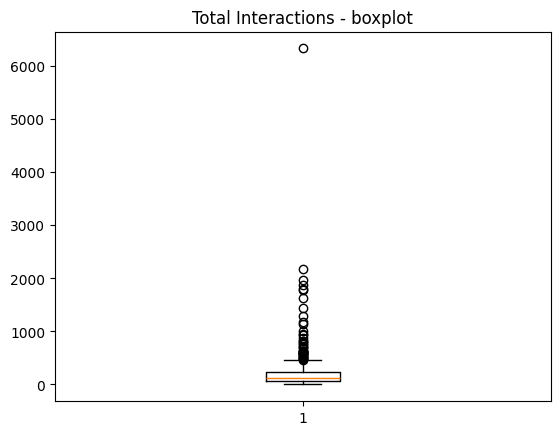

In [8]:
# check for outliers with a boxplot
plt.boxplot(df["Total Interactions"])
plt.title("Total Interactions - boxplot")
plt.show()


## 4. Visualise trends

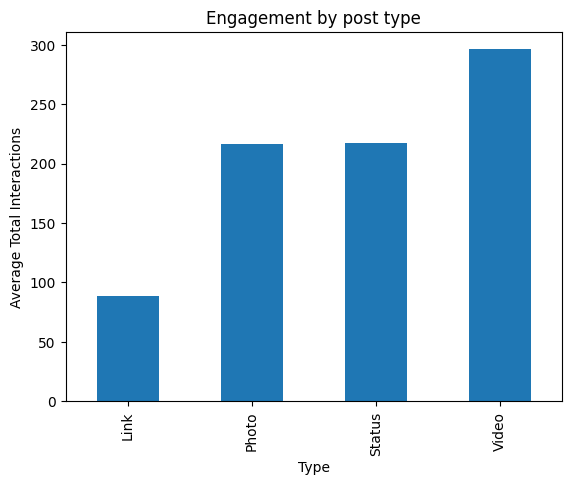

In [9]:
# bar chart: average engagement per post type
df.groupby("Type")["Total Interactions"].mean().plot(kind="bar")
plt.ylabel("Average Total Interactions")
plt.title("Engagement by post type")
plt.show()


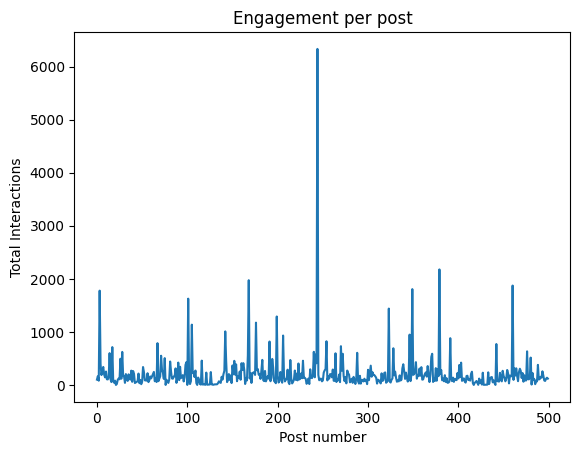

In [10]:
# line chart: engagement across all posts
plt.plot(df["Total Interactions"])
plt.xlabel("Post number")
plt.ylabel("Total Interactions")
plt.title("Engagement per post")
plt.show()


## 5. Prepare data for clustering
We pick the engagement columns and scale them so no single column dominates.

In [11]:
features = ["Lifetime Post Total Reach", "Lifetime Post Total Impressions",
            "Lifetime Engaged Users", "Lifetime Post Consumers",
            "Lifetime Post Consumptions", "comment", "like", "share", "Total Interactions"]

X = df[features]
X_log = np.log1p(X)  # reduces the effect of a few very viral posts

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)


## 6. Elbow method

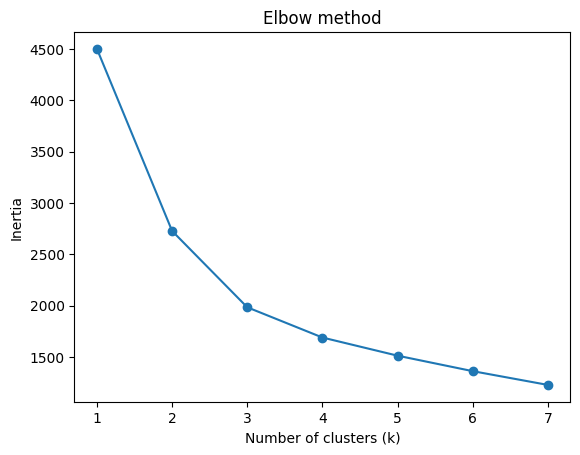

In [12]:
inertia_values = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.plot(range(1, 8), inertia_values, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()


The elbow flattens out around k = 3, so we'll use 3 clusters.

## 7. Algorithm 1: K-Means

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"].value_counts()


,count
kmeans_cluster,
1,293
2,155
0,52


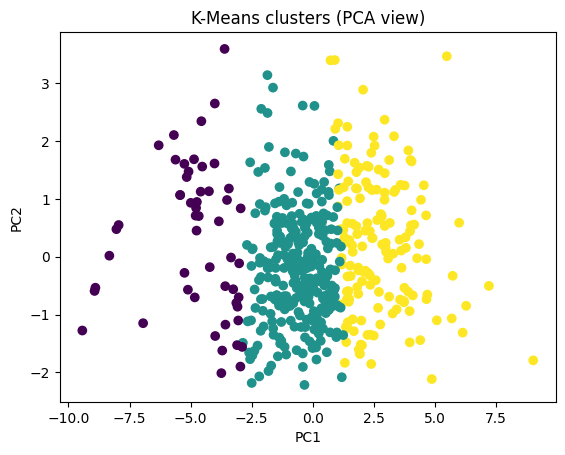

In [14]:
# visualise the clusters in 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["kmeans_cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means clusters (PCA view)")
plt.show()


## 8. Algorithm 2: Agglomerative (hierarchical) clustering

In [15]:
agg = AgglomerativeClustering(n_clusters=3)
df["agg_cluster"] = agg.fit_predict(X_scaled)

df["agg_cluster"].value_counts()


,count
agg_cluster,
1,227
0,200
2,73


## 9. Evaluate the two models

In [16]:
kmeans_score = silhouette_score(X_scaled, df["kmeans_cluster"])
agg_score = silhouette_score(X_scaled, df["agg_cluster"])

print("K-Means silhouette score:", round(kmeans_score, 3))
print("Agglomerative silhouette score:", round(agg_score, 3))


K-Means silhouette score: 0.346
Agglomerative silhouette score: 0.228


A higher silhouette score means better-separated clusters (closer to 1 is better).
K-Means is usually faster and easier to explain, hierarchical clustering also gives you a dendrogram
showing how clusters merge, which is nice for interpretability but slower on big datasets.

## 11. Look at what each cluster means

In [17]:
df.groupby("kmeans_cluster")[features].mean().round(1)


,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,comment,like,share,Total Interactions
kmeans_cluster,,,,,,,,,
0,2101.2,3772.9,178.4,166.9,319.5,0.8,14.0,3.1,17.8
1,5675.0,9611.8,578.9,514.8,848.5,3.4,100.1,19.4,122.8
2,33417.1,76003.4,1814.8,1547.6,2853.9,17.4,379.0,49.6,446.1
